# Experiment 4: Data Analytics I
### Subject: DSBDA (Data Science & Big Data Analytics)

This notebook demonstrates basic **Data Analytics I** using Python and Pandas on Housing Dataset.

### Problem Statement
**Data Analytics I**, 
Create a Linear Regression Model using Python/R to predict home prices using Boston Housing
Dataset (https://www.kaggle.com/c/boston-housing). The Boston Housing dataset contains
information about various houses in Boston through different parameters. There are 506 samples
and 14 feature variables in this dataset.
The objective is to predict the value of prices of the house using the given features.


### Dataset Used
**Housing Dataset** (Housing Data)

Source: https://www.kaggle.com/c/boston-housing


In [10]:
#import the repuired libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#scikit learn models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
#load dataset
df=pd.read_csv("HousingData.csv")

In [3]:
#describe the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
df.shape

(506, 14)

In [8]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [7]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


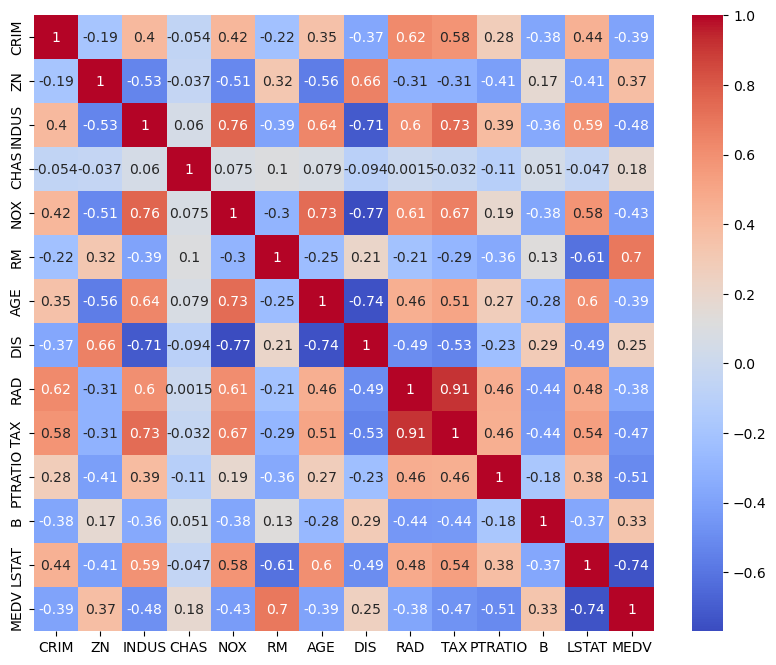

In [11]:
#Check Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [12]:
#split features and target 
X = df.drop('MEDV', axis=1)   # MEDV = price
y = df['MEDV']

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X = df.drop('MEDV', axis=1)
y = df['MEDV']

X = imputer.fit_transform(X)

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train

array([[1.50234000e+01, 0.00000000e+00, 1.81000000e+01, ...,
        2.02000000e+01, 3.49480000e+02, 2.49100000e+01],
       [6.27390000e-01, 0.00000000e+00, 8.14000000e+00, ...,
        2.10000000e+01, 3.95620000e+02, 8.47000000e+00],
       [3.46600000e-02, 1.12119342e+01, 6.06000000e+00, ...,
        1.69000000e+01, 3.62250000e+02, 7.83000000e+00],
       ...,
       [1.50100000e-02, 8.00000000e+01, 2.01000000e+00, ...,
        1.70000000e+01, 3.90940000e+02, 5.99000000e+00],
       [1.11604000e+01, 0.00000000e+00, 1.81000000e+01, ...,
        2.02000000e+01, 1.09850000e+02, 2.32700000e+01],
       [2.28760000e-01, 0.00000000e+00, 8.56000000e+00, ...,
        2.09000000e+01, 7.08000000e+01, 1.06300000e+01]])

In [25]:
y_train

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
       ... 
106    19.5
270    21.1
348    24.5
435    13.4
102    18.6
Name: MEDV, Length: 404, dtype: float64

In [26]:
#train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [29]:
#Predictions
y_pred = model.predict(X_test)

In [30]:
y_pred

array([ 2.91432496e+01,  3.65356675e+01,  1.44925129e+01,  2.50811104e+01,
        1.84560923e+01,  2.30104937e+01,  1.81386861e+01,  1.46265167e+01,
        2.21158938e+01,  2.08706364e+01,  2.50758640e+01,  1.87470982e+01,
       -5.67498472e+00,  2.17286655e+01,  1.90464014e+01,  2.54293420e+01,
        1.96620047e+01,  6.12420178e+00,  4.09972355e+01,  1.72352716e+01,
        2.48905259e+01,  3.02961849e+01,  1.18008779e+01,  2.29655895e+01,
        1.73451595e+01,  1.51051621e+01,  2.10901065e+01,  1.44883316e+01,
        2.30923960e+01,  1.94365043e+01,  2.25439953e+01,  2.52375663e+01,
        2.59309510e+01,  1.66289054e+01,  1.64513986e+01,  1.66143478e+01,
        3.11105960e+01,  2.02837991e+01,  2.43569451e+01,  2.26326769e+01,
        1.45257750e+01,  3.23698301e+01,  4.30428488e+01,  1.76390763e+01,
        2.76326197e+01,  1.64305143e+01,  1.42484248e+01,  2.61635938e+01,
        1.97678160e+01,  3.01463483e+01,  2.09688785e+01,  3.38338873e+01,
        1.64161397e+01,  

In [31]:
#Evaluate Model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 25.01767202384288
RMSE: 5.001766890194192
R2 Score: 0.6588520195508115


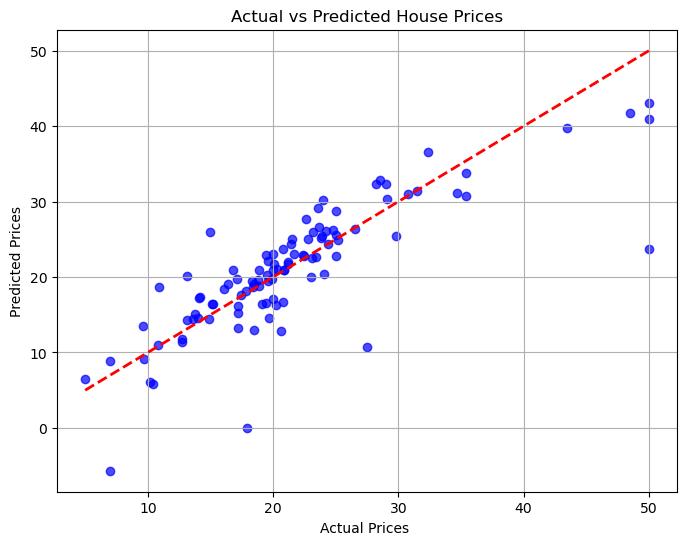

In [38]:
#Visualize Results Scatter plot of Actual vs Predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Prices ')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.grid(True)
plt.show()